# Part 4: Advanced reinforcement learning

While the fundamentals of reinforcement learning focus on value-based approaches like Q-Learning, SARSA, and Monte Carlo, advanced reinforcement learning explores a richer set of tools for solving more complex decision-making problems. These methods go beyond tabular environments and allow agents to handle larger state spaces, continuous actions, and more sophisticated exploration strategies. Instead of relying solely on value functions, advanced RL introduces policy-based methods, actor-critic approaches, eligibility traces, and model-based planning as key extensions to the foundational ideas.

In addition, advanced reinforcement learning broadens the scope of what agents can learn by considering frameworks such as multi-armed bandits for exploration, hierarchical RL for temporally extended actions, and multi-agent RL for cooperative and competitive interactions. Together, these methods provide the stepping stones between classical RL and deep reinforcement learning, equipping learners with the conceptual and practical foundation to understand both algorithmic innovations and real-world applications.

**Policy based methods**

Value-based methods like Q-Learning and SARSA indirectly define a policy by estimating action-value functions and then acting greedily. However, in many environments — especially with large or continuous action spaces — it can be more effective to learn the policy directly. Policy-based methods do this by parameterizing the policy $\pi(a|s, \theta)$, often as a probability distribution over actions given states, and adjusting the parameters $\theta$ to maximize expected rewards.

The key result is the Policy Gradient Theorem, which shows how to estimate gradients of expected returns with respect to policy parameters, allowing us to perform gradient ascent. The simplest algorithm derived from this is REINFORCE, which uses sampled returns from complete episodes to update policy parameters. While it has high variance, it introduces the important idea of optimizing policies directly rather than relying only on value functions.

Example code:

In [6]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")
n_actions = env.action_space.n
n_features = env.observation_space.shape[0]

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def policy(state, theta):
    z = state @ theta
    return softmax(z)

def generate_episode(theta):
    states, actions, rewards = [], [], []

    state, info = env.reset()
    done = False

    while not done:
        probs = policy(state, theta)
        action = np.random.choice(len(probs), p=probs)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state

    return states, actions, rewards

def compute_returns(rewards, gamma=0.99):
    G = np.zeros(len(rewards))
    G_t = 0

    for t in reversed(range(len(rewards))):
        G_t = rewards[t] + gamma * G_t
        G[t] = G_t

    return G

theta = np.random.rand(n_features, n_actions) * 0.01
alpha = 0.01
episodes = 1000

for ep in range(episodes):
    states, actions, rewards = generate_episode(theta)
    returns = compute_returns(rewards)

    for t in range(len(states)):
        probs = policy(states[t], theta)
        grad = -probs.copy()
        grad[actions[t]] += 1
        theta += alpha * returns[t] * np.outer(states[t], grad)

    if (ep + 1) % 100 == 0:
        print(f"Episode {ep+1}: Total Reward = {sum(rewards)}")

Episode 100: Total Reward = 154.0
Episode 200: Total Reward = 183.0
Episode 300: Total Reward = 377.0
Episode 400: Total Reward = 182.0
Episode 500: Total Reward = 200.0
Episode 600: Total Reward = 210.0
Episode 700: Total Reward = 215.0
Episode 800: Total Reward = 304.0
Episode 900: Total Reward = 273.0
Episode 1000: Total Reward = 37.0


**Actor-Critic Methods**

Value-based methods like Q-Learning and SARSA learn only value functions, while policy-based methods like REINFORCE learn only policies. Both have strengths and weaknesses: value-based methods are sample efficient but struggle with large or continuous action spaces, while policy-based methods handle those spaces naturally but suffer from high variance in their updates. Actor-Critic methods combine the best of both worlds by using two models: an actor that learns the policy and a critic that evaluates the policy through value function estimation.

The actor decides which actions to take by maintaining a parameterized policy. Meanwhile, the critic estimates the expected return (or advantage) of the current state or state-action pair. The critic’s evaluation serves as a baseline for the actor’s policy updates, which reduces the variance compared to Monte Carlo policy gradients like REINFORCE. This makes learning more stable and efficient, especially in environments with long horizons or sparse rewards.

In practice, the actor updates the policy parameters in the direction suggested by the critic’s feedback, while the critic updates its value function parameters using temporal-difference learning. This interaction between actor and critic allows the agent to continuously improve both its policy and its evaluation of future rewards. Actor-Critic methods are foundational for many modern reinforcement learning algorithms, providing a flexible framework that scales to larger and more complex problems.

In [9]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")

n_actions = env.action_space.n
n_features = env.observation_space.shape[0]

# Actor parameters (policy)
theta = np.random.rand(n_features, n_actions) * 0.01
# Critic parameters (state-value function)
w = np.random.rand(n_features) * 0.01

alpha_actor = 0.01
alpha_critic = 0.1
gamma = 0.99

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def policy(state):
    z = state @ theta
    return softmax(z)

def value(state):
    return state @ w

episodes = 500
for ep in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        probs = policy(state)
        action = np.random.choice(n_actions, p=probs)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # TD error (advantage estimate)
        td_target = reward + gamma * (0 if done else value(next_state))
        td_error = td_target - value(state)

        # Critic update
        w += alpha_critic * td_error * state

        # Actor update
        grad = -probs.copy()
        grad[action] += 1
        theta += alpha_actor * td_error * np.outer(state, grad)

        state = next_state

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}: Total Reward = {total_reward}")

Episode 50: Total Reward = 26.0
Episode 100: Total Reward = 8.0
Episode 150: Total Reward = 10.0
Episode 200: Total Reward = 18.0
Episode 250: Total Reward = 22.0
Episode 300: Total Reward = 10.0
Episode 350: Total Reward = 9.0
Episode 400: Total Reward = 17.0
Episode 450: Total Reward = 9.0
Episode 500: Total Reward = 8.0


**Eligibility Traces**

In reinforcement learning, there is often a trade-off between Monte Carlo methods and Temporal Difference (TD) methods. Monte Carlo uses complete returns from episodes, which can lead to unbiased estimates but with high variance and slow learning. TD methods, on the other hand, update after each step using bootstrapped estimates, which provides faster updates but can introduce bias. Eligibility traces offer a way to combine the strengths of both approaches into a single, more flexible method.

An eligibility trace is essentially a short-term memory of how recently each state (or state-action pair) was visited. When an update occurs, not only is the most recent state updated, but also previous states receive credit in proportion to how recently and frequently they were visited. This allows information to propagate more efficiently through the state space. The influence of past states decays over time, controlled by the parameter $\lambda$, which determines the balance between Monte Carlo (when $\lambda = 1$) and TD(0) (when $\lambda = 0$).

The resulting algorithm, often referred to as TD(λ), creates a continuum between pure Monte Carlo and pure TD methods. In practice, this flexibility often leads to faster and more stable learning, because eligibility traces ensure that credit (or blame) for outcomes is assigned not just to the most recent decision but to a sequence of prior decisions. This makes eligibility traces a powerful tool in environments where delayed rewards are common, helping the agent to “connect the dots” between earlier actions and later outcomes more effectively.



Code Example: SARSA(λ) with Eligibility Traces on CliffWalking

In [13]:
import numpy as np
import gymnasium as gym

env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))
E = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.99
lam = 0.9
epsilon = 0.1
episodes = 500

def epsilon_greedy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

for ep in range(episodes):
    state, _ = env.reset()
    action = epsilon_greedy(state, epsilon)
    E.fill(0)
    total_reward = 0
    done = False

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_action = epsilon_greedy(next_state, epsilon)

        td_error = reward + gamma * Q[next_state, next_action] * (not done) - Q[state, action]

        E[state, action] += 1
        Q += alpha * td_error * E
        E *= gamma * lam

        state, action = next_state, next_action
        total_reward += reward

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}: Total Reward = {total_reward}")

Episode 50: Total Reward = -25
Episode 100: Total Reward = -17
Episode 150: Total Reward = -25
Episode 200: Total Reward = -17
Episode 250: Total Reward = -19
Episode 300: Total Reward = -19
Episode 350: Total Reward = -19
Episode 400: Total Reward = -20
Episode 450: Total Reward = -21
Episode 500: Total Reward = -25


**Model-based methods**

In the reinforcement learning frameworks we’ve discussed so far (Monte Carlo, TD, SARSA, Q-Learning, Actor-Critic), the agent learns purely from trial and error with the environment. These are known as model-free methods because they don’t assume any knowledge about how the environment works. While powerful, they can require a lot of data to learn effective policies.

Model-based reinforcement learning (MBRL) takes a different approach: in addition to learning a policy or value function, the agent also tries to learn a model of the environment. This model captures the transition dynamics (how states evolve when actions are taken) and sometimes the reward function. Once a model is learned, the agent can use it to plan ahead, simulating possible future trajectories without needing to interact with the real environment at every step.

One well-known algorithm in this area is Dyna-Q. It combines direct reinforcement learning with planning: the agent interacts with the environment to update Q-values as in Q-Learning, but it also uses its learned model to generate additional "imaginary" experiences that help update Q-values more efficiently. This means the agent gets more out of each real interaction, leading to faster convergence and better sample efficiency.

Code example:



In [18]:
import numpy as np
import gymnasium as gym
from collections import defaultdict

env = gym.make("CliffWalking-v1")

n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))
model = defaultdict(tuple)   # maps (state, action) -> (next_state, reward)

alpha = 0.1
gamma = 0.99
epsilon = 0.1
planning_steps = 20
episodes = 300

def epsilon_greedy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

for ep in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Direct RL update (Q-learning)
        best_next = 0 if done else np.max(Q[next_state])
        Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])

        # Update model
        model[(state, action)] = (next_state, reward)

        # Planning updates
        model_keys = list(model.keys())
        for _ in range(planning_steps):
            s, a = model_keys[np.random.randint(len(model_keys))]
            s_next, r = model[(s, a)]
            best_next_model = np.max(Q[s_next])
            Q[s, a] += alpha * (r + gamma * best_next_model - Q[s, a])

        state = next_state
        total_reward += reward

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1}: Total Reward = {total_reward}")

Episode 50: Total Reward = -13
Episode 100: Total Reward = -122
Episode 150: Total Reward = -15
Episode 200: Total Reward = -14
Episode 250: Total Reward = -15
Episode 300: Total Reward = -19


### Multi-armed bandits

 The multi-armed bandit problem is one of the simplest yet most fundamental settings in reinforcement learning. Imagine standing in front of several slot machines (“one-armed bandits”), each with an unknown payout probability. At each step, you must choose which machine to pull. Your goal is to maximize your total reward over time. The challenge is the classic exploration vs. exploitation dilemma: do you exploit the machine that seems best so far, or explore other machines that might yield higher rewards in the long run?

MABs don’t involve state transitions — the problem is purely about choosing actions and estimating their expected rewards. This makes them an excellent starting point for studying exploration strategies and for understanding reinforcement learning at its core. Common algorithms include:

- ε-greedy: with probability ε, explore randomly; otherwise, exploit the best-known action.
- Upper Confidence Bound (UCB): balances reward estimates with uncertainty, encouraging exploration of less-tried actions.
- Thompson Sampling: uses probability distributions to sample actions based on their likelihood of being optimal.

These strategies are the foundation of exploration-exploitation trade-offs in larger RL problems.

In [2]:
import numpy as np

# Simulated slot machines with unknown true probabilities
true_means = [0.2, 0.5, 0.75]  # each bandit has a different payout chance
n_bandits = len(true_means)
n_steps = 1000
epsilon = 0.1

# Initialize estimates
Q = np.zeros(n_bandits)   # estimated values
N = np.zeros(n_bandits)   # action counts
rewards = []

for t in range(n_steps):
    # ε-greedy action selection
    if np.random.rand() < epsilon:
        action = np.random.randint(n_bandits)
    else:
        action = np.argmax(Q)

    # Simulate reward from chosen bandit
    reward = 1 if np.random.rand() < true_means[action] else 0

    # Update estimates
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]  # incremental mean update

    rewards.append(reward)

print(f"Estimated means: {Q}")
print(f"True means: {true_means}")
print(f"Total reward: {sum(rewards)}")

Estimated means: [0.14754098 0.51351351 0.75388027]
True means: [0.2, 0.5, 0.75]
Total reward: 708


## Exercise

Environment idea

Agent starts in the top-left (0,0)
Goal is bottom-right (3,3)
Reward = +1 at the goal, 0 elsewhere
Episode ends when the goal is reached

In [4]:
import numpy as np
import random

# Grid size
n = 4

# Rewards
grid_rewards = np.zeros((n, n))
grid_rewards[3, 3] = 1  # goal

# Actions: 0=up, 1=right, 2=down, 3=left
actions = [0, 1, 2, 3]

def step(state, action):
    """Takes a step in the gridworld"""
    x, y = state

    if action == 0:    # up
        x = max(x - 1, 0)
    elif action == 1:  # right
        y = min(y + 1, n - 1)
    elif action == 2:  # down
        x = min(x + 1, n - 1)
    elif action == 3:  # left
        y = max(y - 1, 0)

    next_state = (x, y)
    reward = grid_rewards[x, y]
    done = (next_state == (3, 3))

    return next_state, reward, done


Monte Carlo Prediction (First-Visit)

Key idea

Run full episodes
After the episode finishes, work backwards
Update a state’s value using the average return
Only update the first time a state appears in an episode

In [6]:
V_mc = np.zeros((n, n))
returns_count = np.zeros((n, n))

gamma = 0.9
episodes = 5000

for _ in range(episodes):
    state = (0, 0)
    episode = []

    # Generate one episode (random policy)
    while True:
        action = random.choice(actions)
        next_state, reward, done = step(state, action)
        episode.append((state, reward))
        state = next_state
        if done:
            break

    # Compute returns (backwards)
    G = 0
    visited = set()

    for state, reward in reversed(episode):
        G = reward + gamma * G
        if state not in visited:  # first-visit
            x, y = state
            returns_count[x, y] += 1
            V_mc[x, y] += (G - V_mc[x, y]) / returns_count[x, y]
            visited.add(state)


TD(0): Temporal Difference Learning

Key idea

Update after every step
No need to wait for episode to finish
Learns faster, but slightly biased
Code: TD(0)

In [8]:
V_td = np.zeros((n, n))
alpha = 0.1
gamma = 0.9
episodes = 5000

for _ in range(episodes):
    state = (0, 0)

    while True:
        action = random.choice(actions)
        next_state, reward, done = step(state, action)

        x, y = state
        nx, ny = next_state

        # TD(0) update
        V_td[x, y] += alpha * (
            reward + gamma * V_td[nx, ny] - V_td[x, y]
        )

        state = next_state
        if done:
            break


4️⃣ TD(λ): Eligibility Traces

Intuition

TD(0): only updates current state
Monte Carlo: updates everything at the end
TD(λ): spreads credit backwards smoothly

Think of eligibility traces as memory of recently visited states.

Code: TD(λ)

In [10]:
V_tdl = np.zeros((n, n))
alpha = 0.1
gamma = 0.9
lambda_ = 0.8
episodes = 5000

for _ in range(episodes):
    state = (0, 0)
    E = np.zeros((n, n))  # eligibility traces

    while True:
        action = random.choice(actions)
        next_state, reward, done = step(state, action)

        x, y = state
        nx, ny = next_state

        delta = reward + gamma * V_tdl[nx, ny] - V_tdl[x, y]

        # Update eligibility trace
        E[x, y] += 1

        # Update all states
        V_tdl += alpha * delta * E

        # Decay traces
        E *= gamma * lambda_

        state = next_state
        if done:
            break


In [11]:
print("Monte Carlo Value Function:\n", np.round(V_mc, 2))
print("\nTD(0) Value Function:\n", np.round(V_td, 2))
print("\nTD(λ) Value Function:\n", np.round(V_tdl, 2))


Monte Carlo Value Function:
 [[0.19 0.25 0.31 0.33]
 [0.25 0.35 0.46 0.52]
 [0.31 0.46 0.65 0.8 ]
 [0.33 0.52 0.79 0.  ]]

TD(0) Value Function:
 [[0.07 0.09 0.12 0.16]
 [0.08 0.11 0.2  0.24]
 [0.12 0.19 0.27 0.36]
 [0.14 0.28 0.51 0.  ]]

TD(λ) Value Function:
 [[0.09 0.1  0.11 0.22]
 [0.11 0.12 0.11 0.25]
 [0.09 0.15 0.26 0.39]
 [0.07 0.15 0.48 0.  ]]


What you’ll notice

- MC: noisy but accurate eventually
- TD(0): smoother, faster
- TD(λ): often fastest + smoothest

6️⃣ Multi-Armed Bandit (ε-Greedy)

Problem

3 slot machines
Each has a hidden reward probability
You want to learn which one is best
Setup

In [14]:
true_means = [0.3, 0.6, 0.8]
epsilon = 0.1
steps = 5000

Q = np.zeros(3)       # estimated means
N = np.zeros(3)       # action counts
rewards = []


In [15]:
# ε-Greedy Loop
for t in range(steps):

    # Choose action
    if random.random() < epsilon:
        action = random.randint(0, 2)  # explore
    else:
        action = np.argmax(Q)           # exploit

    # Pull arm
    reward = 1 if random.random() < true_means[action] else 0

    # Update estimates
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

    rewards.append(reward)


In [16]:
print("True means:", true_means)
print("Estimated means:", np.round(Q, 2))
print("Total reward:", sum(rewards))


True means: [0.3, 0.6, 0.8]
Estimated means: [0.33 0.6  0.81]
Total reward: 3908


| Concept     | What it answers                                |
| ----------- | ---------------------------------------------- |
| Monte Carlo | “What was the total outcome of this episode?”  |
| TD(0)       | “Did this step turn out better than expected?” |
| TD(λ)       | “Which recent states deserve credit?”          |
| ε-Greedy    | “Should I exploit or explore right now?”       |


### Hierarchical Reinforcement Learning

Hierarchical Reinforcement Learning extends traditional RL by decomposing complex tasks into smaller, more manageable sub-tasks. Instead of learning a single monolithic policy over all possible actions, HRL organizes actions and decisions into layers of hierarchy. This allows agents to solve large-scale problems more efficiently, reusing learned skills or sub-policies across different tasks.

A core idea in HRL is the temporal abstraction of actions, often called options or macro-actions. Each option represents a sub-policy that the agent can execute for multiple time steps, rather than deciding one primitive action at a time. This reduces the effective horizon of the problem and improves learning speed, particularly in environments where rewards are sparse or delayed.

HRL also introduces the concept of a high-level controller, which selects which sub-task (or option) to execute, while a low-level controller handles the execution details of that sub-task. This separation enables modular learning and facilitates transfer between related tasks. Classic HRL approaches include the Options Framework, MAXQ Value Function Decomposition, and Feudal Reinforcement Learning, each proposing different ways to structure and optimize hierarchies of decisions.

Code examples:

Options Framework

The Options Framework introduces temporal abstractions (options) that are sub-policies executed for multiple steps. Here’s a simple gridworld example:

In [20]:
import numpy as np
import random

# Simple GridWorld
grid_size = 5
goal = (4, 4)

# Define options (sub-policies)
def move_right(state):
    x, y = state
    return (min(x+1, grid_size-1), y)

def move_down(state):
    x, y = state
    return (x, min(y+1, grid_size-1))

options = [move_right, move_down]

# High-level policy: choose option
def high_level_policy(state):
    if state[0] < goal[0]:
        return move_right
    elif state[1] < goal[1]:
        return move_down
    else:
        return None

# Simulation
state = (0, 0)
trajectory = [state]

while state != goal:
    option = high_level_policy(state)
    if option is None:
        break
    # Execute option until termination (here 1 step per option for simplicity)
    state = option(state)
    trajectory.append(state)

print("Trajectory:", trajectory)

Trajectory: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


MAXQ Value Function Decomposition

MAXQ decomposes the value function into hierarchically structured sub-tasks:

In [22]:
# Sub-tasks: move_right, move_down, reach_goal
subtasks = ['move_right', 'move_down', 'reach_goal']

# Q-values for each sub-task
Q = {task: {} for task in subtasks}

# Initialize Q-values
for task in subtasks:
    for x in range(grid_size):
        for y in range(grid_size):
            Q[task][(x, y)] = 0.0

# Reward function
def reward(state):
    return 1 if state == goal else 0

# MAXQ update (simplified)
def maxq_update(task, state, next_state, alpha=0.1, gamma=0.9):
    r = reward(next_state)
    Q[task][state] += alpha * (r + gamma * Q[task][next_state] - Q[task][state])

# Example one-step update
state = (0, 0)
next_state = (1, 0)  # Assume move_right
maxq_update('move_right', state, next_state)
print("Updated Q-move_right:", Q['move_right'][(0,0)])

Updated Q-move_right: 0.0


Feudal Reinforcement Learning

Feudal RL separates decision-making into managers and workers. The manager sets sub-goals, and the worker executes primitive actions to achieve them:

In [24]:
# Define manager sub-goal
def manager_policy(state):
    # Set sub-goal: reach column 4
    return (4, state[1])

# Define worker to achieve manager sub-goal
def worker_policy(state, sub_goal):
    x, y = state
    goal_x, goal_y = sub_goal
    if x < goal_x:
        return (x+1, y)
    elif x > goal_x:
        return (x-1, y)
    else:
        return state  # Already at sub-goal

# Simulation
state = (0, 0)
trajectory = [state]

while state != goal:
    sub_goal = manager_policy(state)
    state = worker_policy(state, sub_goal)
    trajectory.append(state)

print("Feudal RL trajectory:", trajectory)

Traceback (most recent call last):
Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 176, in zmq.backend.cython._zmq._check_rc
  File "/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_1029/721740369.py", line 23, in <module>
    state = worker_policy(state, sub_goal)
  File "/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_1029/721740369.py", line 7, in worker_policy
    def worker_policy(state, sub_goal):
    
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 176, in zmq.backend.cython._zmq._check_rc
    PyErr_Chec

KeyboardInterrupt: 

### Multi-agent Reinforcement learning

Multi-Agent Reinforcement Learning extends standard RL to environments where multiple agents interact, each learning and adapting in the presence of others. Unlike single-agent RL, the environment for any individual agent is non-stationary, because other agents are simultaneously learning and changing their policies. This leads to complex dynamics such as cooperation, competition, and communication, which require new strategies beyond classic RL techniques.

In MARL, the core objectives often include maximizing individual rewards, achieving group-level goals, or balancing between cooperation and competition. Challenges in this domain include coordination, credit assignment, and scalability, as the joint action space grows exponentially with the number of agents. To address these challenges, MARL methods often leverage centralized training with decentralized execution, where agents learn together in simulation but act independently in deployment.



Key Concepts in MARL

1. Types of Interactions
- Cooperative: All agents share a common goal, e.g., multi-robot path planning.
- Competitive: Agents compete for resources or rewards, e.g., multi-player games.
- Mixed: Some agents cooperate while others compete, e.g., team-based sports simulations.

2. Policy and Value Function Extensions
- Each agent can have its own policy and value function, but these may also be conditioned on other agents’ actions or states.
- Methods like Independent Q-Learning treat other agents as part of the environment, while Centralized Q-Learning considers joint actions.

3. Exploration vs. Exploitation in MARL
- Standard exploration strategies (like ε-greedy) become more complex, because an agent’s environment is dynamic and depends on other agents’ policies.

4. Communication and Coordination
- Agents may share information through explicit communication channels or implicit signaling.
- Techniques like value decomposition networks (VDN) and QMIX help in cooperative scenarios by decomposing global rewards into agent-specific contributions.

https://www.mathworks.com/help/reinforcement-learning/ug/train-3-agents-for-area-coverage.html?s_eid=PSM_15028


In [26]:
# Code Example: Independent Q-Learning for Two Agents

import numpy as np
import random

# Define GridWorld
grid_size = 4
num_states = grid_size * grid_size
num_actions = 4  # 0: up, 1: right, 2: down, 3: left

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 500

# Initialize Q-tables for two agents
Q_agent1 = np.zeros((num_states, num_actions))
Q_agent2 = np.zeros((num_states, num_actions))

# Reward function (agents reach bottom-right corner to get reward)
def get_reward(state1, state2):
    goal_state = num_states - 1
    reward1 = 1 if state1 == goal_state else 0
    reward2 = 1 if state2 == goal_state else 0
    return reward1, reward2

# State transition function
def step(state, action):
    row, col = divmod(state, grid_size)
    if action == 0 and row > 0: row -= 1
    if action == 1 and col < grid_size-1: col += 1
    if action == 2 and row < grid_size-1: row += 1
    if action == 3 and col > 0: col -= 1
    return row * grid_size + col

# Training loop
for episode in range(episodes):
    state1 = 0  # agent1 starts top-left
    state2 = 0  # agent2 starts top-left
    done = False

    while not done:
        # ε-greedy action selection
        action1 = np.argmax(Q_agent1[state1]) if random.random() > epsilon else random.randint(0, num_actions-1)
        action2 = np.argmax(Q_agent2[state2]) if random.random() > epsilon else random.randint(0, num_actions-1)

        # Step environment
        next_state1 = step(state1, action1)
        next_state2 = step(state2, action2)

        # Get rewards
        reward1, reward2 = get_reward(next_state1, next_state2)

        # Update Q-tables
        Q_agent1[state1, action1] += alpha * (reward1 + gamma * np.max(Q_agent1[next_state1]) - Q_agent1[state1, action1])
        Q_agent2[state2, action2] += alpha * (reward2 + gamma * np.max(Q_agent2[next_state2]) - Q_agent2[state2, action2])

        # Move to next state
        state1, state2 = next_state1, next_state2

        # End episode if both agents reached goal
        if state1 == num_states-1 and state2 == num_states-1:
            done = True

print("Training finished.\n")
print("Sample Q-values Agent 1:\n", Q_agent1[:5])
print("Sample Q-values Agent 2:\n", Q_agent2[:5])

Training finished.

Sample Q-values Agent 1:
 [[4.97654987e+00 5.85184732e+00 3.77749778e+00 4.66894977e+00]
 [4.75848449e+00 6.50897856e+00 4.07222743e+00 4.87612665e+00]
 [5.77082507e+00 6.20925189e+00 7.23925269e+00 5.14682279e+00]
 [1.33227162e+00 1.59917765e+00 7.95375251e+00 6.85589954e-01]
 [4.94054133e+00 3.82888628e-05 3.23815955e-02 7.63811487e-01]]
Sample Q-values Agent 2:
 [[5.03548409 5.9049     3.93950589 4.78722478]
 [5.81767582 6.561      5.00772595 5.18628927]
 [6.44126477 7.05294061 7.29       5.73859425]
 [3.35252545 4.76287926 8.09350186 2.68675703]
 [5.09690509 0.51625948 0.04609394 1.15760695]]


In [27]:
# Code Example: Cooperative Q-Learning with Shared Reward

import numpy as np
import random

# Define GridWorld
grid_size = 4
num_states = grid_size * grid_size
num_actions = 4  # 0: up, 1: right, 2: down, 3: left

# Hyperparameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 500

# Initialize Q-tables for two agents
Q_agent1 = np.zeros((num_states, num_actions))
Q_agent2 = np.zeros((num_states, num_actions))

# Reward function (shared reward)
def get_shared_reward(state1, state2):
    goal_state = num_states - 1
    reward = 1 if state1 == goal_state and state2 == goal_state else 0
    return reward

# State transition function
def step(state, action):
    row, col = divmod(state, grid_size)
    if action == 0 and row > 0: row -= 1
    if action == 1 and col < grid_size-1: col += 1
    if action == 2 and row < grid_size-1: row += 1
    if action == 3 and col > 0: col -= 1
    return row * grid_size + col

# Training loop
for episode in range(episodes):
    state1 = 0
    state2 = 0
    done = False

    while not done:
        # ε-greedy action selection
        action1 = np.argmax(Q_agent1[state1]) if random.random() > epsilon else random.randint(0, num_actions-1)
        action2 = np.argmax(Q_agent2[state2]) if random.random() > epsilon else random.randint(0, num_actions-1)

        # Step environment
        next_state1 = step(state1, action1)
        next_state2 = step(state2, action2)

        # Shared reward
        reward = get_shared_reward(next_state1, next_state2)

        # Update Q-tables independently but using shared reward
        Q_agent1[state1, action1] += alpha * (reward + gamma * np.max(Q_agent1[next_state1]) - Q_agent1[state1, action1])
        Q_agent2[state2, action2] += alpha * (reward + gamma * np.max(Q_agent2[next_state2]) - Q_agent2[state2, action2])

        state1, state2 = next_state1, next_state2

        if state1 == num_states-1 and state2 == num_states-1:
            done = True

print("Training finished.\n")
print("Sample Q-values Agent 1:\n", Q_agent1[:5])
print("Sample Q-values Agent 2:\n", Q_agent2[:5])


Training finished.

Sample Q-values Agent 1:
 [[2.50848677 3.21496111 1.7446665  2.37926643]
 [2.61410624 3.58717084 1.66663138 2.55640533]
 [3.13905075 4.01968814 2.76157458 2.48076913]
 [3.40775379 3.6533729  4.52174129 3.29403206]
 [2.51239087 0.13879949 0.11562342 0.04746172]]
Sample Q-values Agent 2:
 [[1.22461055e+00 1.68806041e+00 1.85573330e-01 1.08065942e+00]
 [1.36192020e+00 1.88311119e+00 6.02900760e-01 1.09590612e+00]
 [1.53482322e+00 2.10401623e+00 1.32012352e+00 1.29627951e+00]
 [1.45087560e+00 1.80355129e+00 2.34949141e+00 1.56186984e+00]
 [1.73300719e-07 6.58732283e-01 3.44212049e-02 1.74261886e-07]]


### Hands on practice II:
1 Set up a GridWorld environment
- Grid size: 5×5
- Two agents start at| different corners
- One goal state for both agents
- Requirement: some obstacles or cliffs

2 Implement a two-level hierarchical agent
- High-level policy: selects sub-goals (e.g., intermediate cells to reach the main goal)
- Low-level policy: executes primitive actions to reach the chosen sub-goal

3 Initialize Q-tables
- One Q-table per agent for low-level policy
- One Q-table per agent for high-level policy (sub-goal selection)

4 Train agents cooperatively
- Use shared reward when both agents reach the goal
- Apply ε-greedy exploration
- Update both high-level and low-level Q-tables using tabular Q-learning

5. Visualize results
- Plot trajectories of both agents
- Show the cumulative reward over episodes

Optionally, visualize which sub-goals were selected most frequently by the high-level policy

In [28]:
import numpy as np
import random
import matplotlib.pyplot as plt

GRID_SIZE = 5

START_A = (0, 0)
START_B = (4, 0)
GOAL = (4, 4)

OBSTACLES = {(1,1), (2,1), (3,1), (3,3)}

ACTIONS = {
    0: (-1, 0),  # up
    1: (0, 1),   # right
    2: (1, 0),   # down
    3: (0, -1)   # left
}


In [29]:
def step(state, action):
    dx, dy = ACTIONS[action]
    x, y = state
    nx, ny = x + dx, y + dy

    # Stay in bounds
    nx = max(0, min(GRID_SIZE - 1, nx))
    ny = max(0, min(GRID_SIZE - 1, ny))

    # Hit obstacle → stay put
    if (nx, ny) in OBSTACLES:
        return state

    return (nx, ny)


In [30]:
SUBGOALS = [
    (0, 4),
    (2, 2),
    (4, 2),
    GOAL
]

N_SUBGOALS = len(SUBGOALS)


In [31]:
def init_q_tables():
    Q_low = np.zeros((GRID_SIZE, GRID_SIZE, 4))
    Q_high = np.zeros((GRID_SIZE, GRID_SIZE, N_SUBGOALS))
    return Q_low, Q_high

Q_low_A, Q_high_A = init_q_tables()
Q_low_B, Q_high_B = init_q_tables()


In [32]:
def epsilon_greedy(q_values, epsilon):
    if random.random() < epsilon:
        return random.randint(0, len(q_values) - 1)
    return np.argmax(q_values)


In [33]:
EPISODES = 500
MAX_STEPS = 100

alpha = 0.1
gamma = 0.9
epsilon = 0.1

SUBGOAL_INTERVAL = 5


In [34]:
episode_rewards = []
trajectories = []

for ep in range(EPISODES):

    pos_A, pos_B = START_A, START_B
    traj_A, traj_B = [pos_A], [pos_B]

    # Initial sub-goals
    sg_A = epsilon_greedy(Q_high_A[pos_A], epsilon)
    sg_B = epsilon_greedy(Q_high_B[pos_B], epsilon)

    total_reward = 0

    for step_count in range(MAX_STEPS):

        # --- LOW-LEVEL ACTIONS ---
        a_A = epsilon_greedy(Q_low_A[pos_A], epsilon)
        a_B = epsilon_greedy(Q_low_B[pos_B], epsilon)

        next_A = step(pos_A, a_A)
        next_B = step(pos_B, a_B)

        traj_A.append(next_A)
        traj_B.append(next_B)

        # --- Reward ---
        done_A = (next_A == GOAL)
        done_B = (next_B == GOAL)

        reward = 1 if (done_A and done_B) else 0
        total_reward += reward

        # --- LOW-LEVEL Q UPDATE ---
        Q_low_A[pos_A][a_A] += alpha * (
            reward + gamma * np.max(Q_low_A[next_A]) - Q_low_A[pos_A][a_A]
        )
        Q_low_B[pos_B][a_B] += alpha * (
            reward + gamma * np.max(Q_low_B[next_B]) - Q_low_B[pos_B][a_B]
        )

        pos_A, pos_B = next_A, next_B

        # --- HIGH-LEVEL UPDATE ---
        if step_count % SUBGOAL_INTERVAL == 0:
            Q_high_A[pos_A][sg_A] += alpha * (
                reward + gamma * np.max(Q_high_A[pos_A]) - Q_high_A[pos_A][sg_A]
            )
            Q_high_B[pos_B][sg_B] += alpha * (
                reward + gamma * np.max(Q_high_B[pos_B]) - Q_high_B[pos_B][sg_B]
            )

            sg_A = epsilon_greedy(Q_high_A[pos_A], epsilon)
            sg_B = epsilon_greedy(Q_high_B[pos_B], epsilon)

        if done_A and done_B:
            break

    episode_rewards.append(total_reward)
    trajectories.append((traj_A, traj_B))


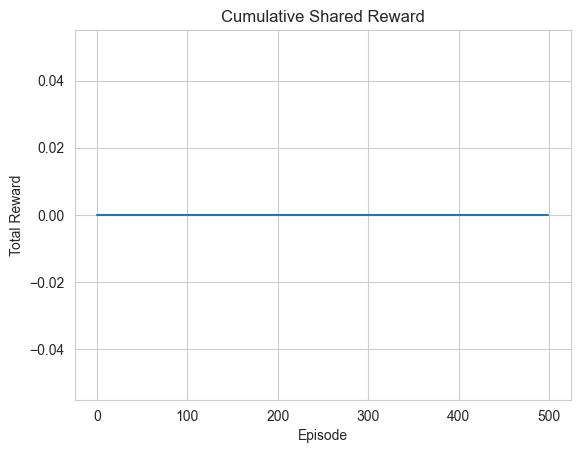

In [35]:
plt.plot(np.cumsum(episode_rewards))
plt.title("Cumulative Shared Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()


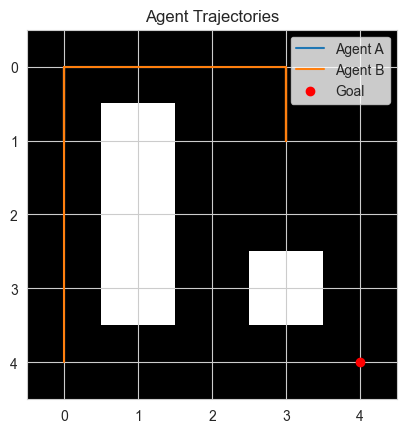

In [36]:
traj_A, traj_B = trajectories[-1]

grid = np.zeros((GRID_SIZE, GRID_SIZE))

for x, y in OBSTACLES:
    grid[x, y] = -1

plt.imshow(grid, cmap="gray_r")

ax = plt.gca()
ax.plot([y for x,y in traj_A], [x for x,y in traj_A], label="Agent A")
ax.plot([y for x,y in traj_B], [x for x,y in traj_B], label="Agent B")

ax.scatter(GOAL[1], GOAL[0], c="red", label="Goal")
ax.legend()
plt.title("Agent Trajectories")
plt.show()


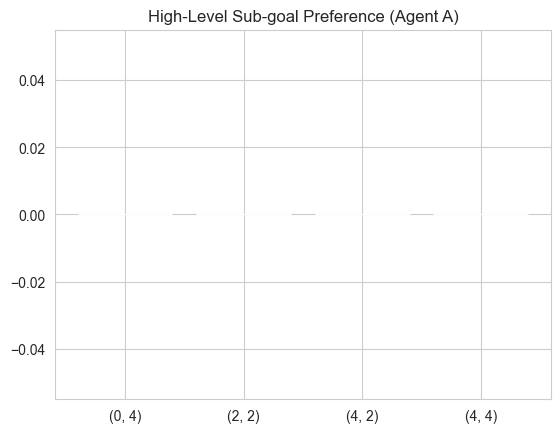

In [37]:
subgoal_usage_A = np.sum(Q_high_A, axis=(0,1))
plt.bar(range(N_SUBGOALS), subgoal_usage_A)
plt.xticks(range(N_SUBGOALS), SUBGOALS)
plt.title("High-Level Sub-goal Preference (Agent A)")
plt.show()
